Final Project


In [7]:
import pandas as pd

df = pd.read_excel('student_performance_dataset (1).xlsx')
print(df.head())

   Student_ID   Name Age  Gender        City Department Education_Level  \
0           1   Uzma  24  Female      Lahore         CS    Intermediate   
1           2  ZAHID  19  female     Karachi         SE    Intermediate   
2           3   Sara  19  Female      Lahore        BBA    Intermediate   
3           4  Zahid  22    Male  Rawalpindi         EE    Intermediate   
4           5  Zahid  21    Male     Karachi         SE    Intermediate   

   Attendance_%  Study_Hours_Daily  Assignments  Quizzes  Midterm  \
0          60.0                7.0          6.0       13     89.0   
1          82.0                4.0          NaN        5     84.0   
2           NaN                5.0         10.0        9     50.0   
3          98.0                7.0          8.0        8     68.0   
4          98.0                3.0          5.0       17     75.0   

  Internet_Access  Final_Score  
0              No           53  
1             Yes           55  
2             Yes           42  
3 

Step 1: Load Data and First Look

In [ ]:
# Import libraries
import pandas as pd

# Load dataset (use YOUR uploaded file name)
df = pd.read_excel('student_performance_dataset (1).xlsx')

# Basic overview
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nInfo:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (205, 14)

Columns: Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Department',
       'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments',
       'Quizzes', 'Midterm', 'Internet_Access', 'Final_Score'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  

,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49



Last 5 rows:


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40



Statistical Summary:


,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000



Missing Values:
Student_ID            0
Name                  0
Age                   0
Gender                0
City                  0
Department            0
Education_Level       0
Attendance_%         16
Study_Hours_Daily     5
Assignments          10
Quizzes               0
Midterm              10
Internet_Access       0
Final_Score           0
dtype: int64


Observations:-
1.Dataset contains missing values in multiple columns
2.Some columns have inconsistent formatting (Gender, Name, Department)
3.Data type issues exist in Age column

STEP 2 — Data Cleaning


In [ ]:
# Fix Gender casing
df['Gender'] = df['Gender'].str.title()

# Fix Name casing
df['Name'] = df['Name'].str.title()

# Fix Department inconsistencies
df['Department'] = df['Department'].str.upper().str.strip()

# Fix Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fix Attendance
df.loc[(df['Attendance_%'] < 0) | (df['Attendance_%'] > 100), 'Attendance_%'] = None
df['Attendance_%'] = df['Attendance_%'].fillna(df['Attendance_%'].median())

# Fix Final Score
df.loc[df['Final_Score'] > 100, 'Final_Score'] = None
df['Final_Score'] = df['Final_Score'].fillna(df['Final_Score'].median())

# Fill missing values
for col in ['Assignments', 'Quizzes', 'Midterm', 'Study_Hours_Daily']:
    df[col] = df[col].fillna(df[col].median())

# Remove duplicates
df = df.drop_duplicates()

# Final check
print(df.isnull().sum())

Student_ID             0
Name                   0
Age                    0
Gender                 0
City                   0
Department             0
Education_Level        0
Attendance_%           0
Study_Hours_Daily      0
Assignments            0
Quizzes                0
Midterm                0
Internet_Access        0
Final_Score            0
Total_Academic         0
Attendance_Category    0
dtype: int64


Justifications:-
The inplace parameter was avoided to prevent chained assignment warnings and ensure compatibility with future versions of pandas. Instead, values were reassigned directly to the dataframe columns

STEP 3 — EDA + Visualization

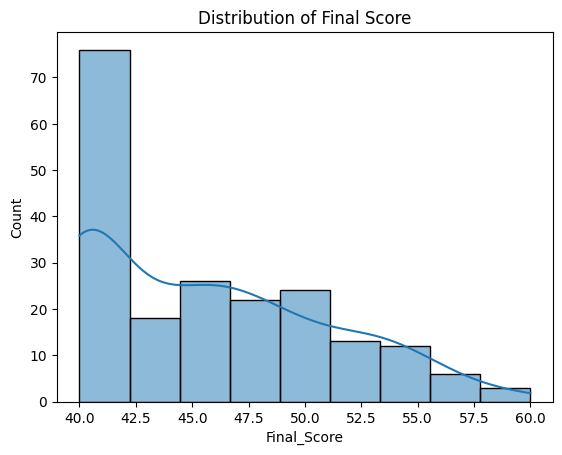

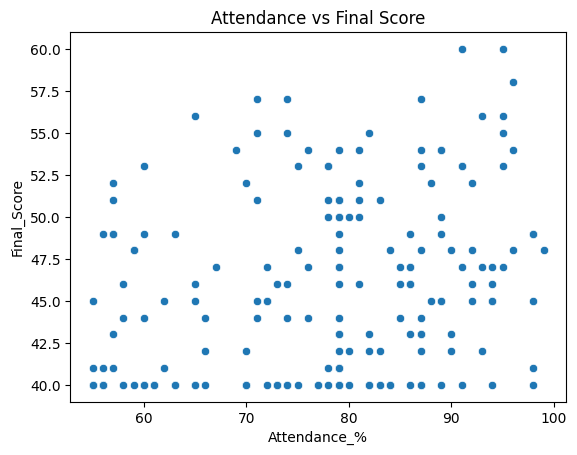

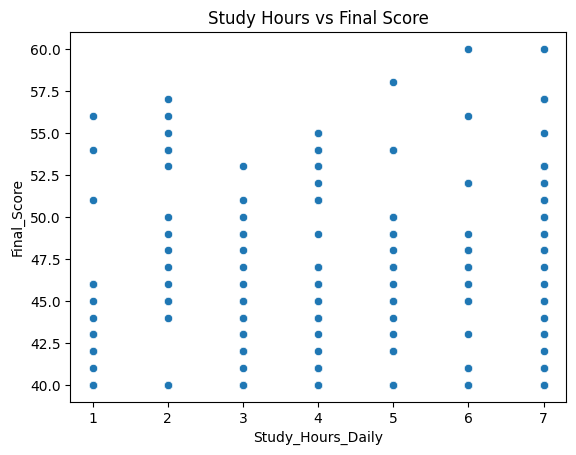

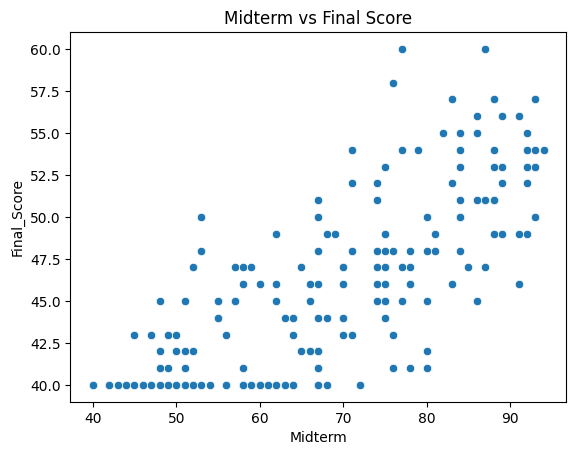

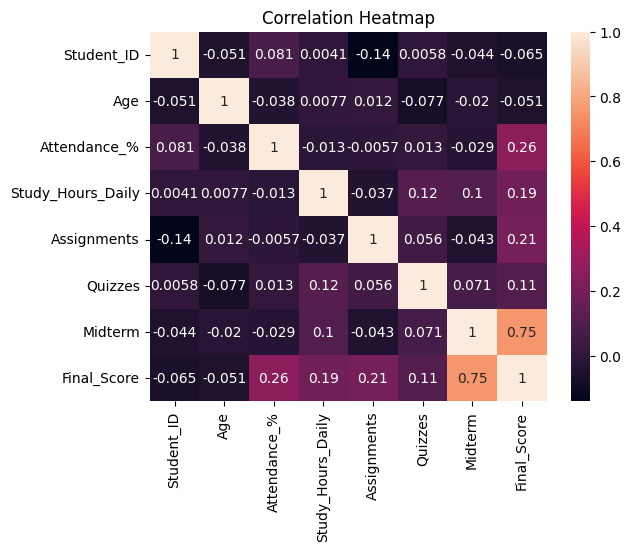

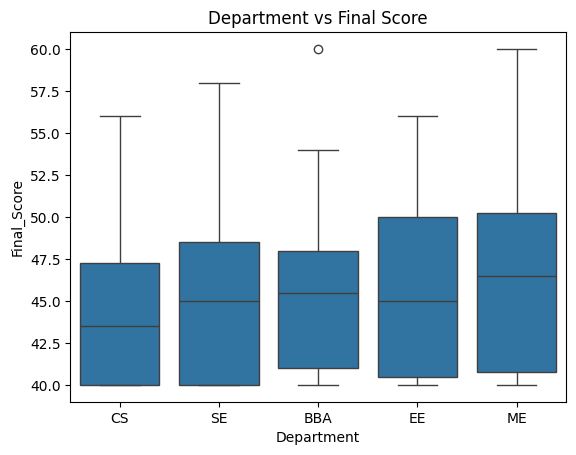

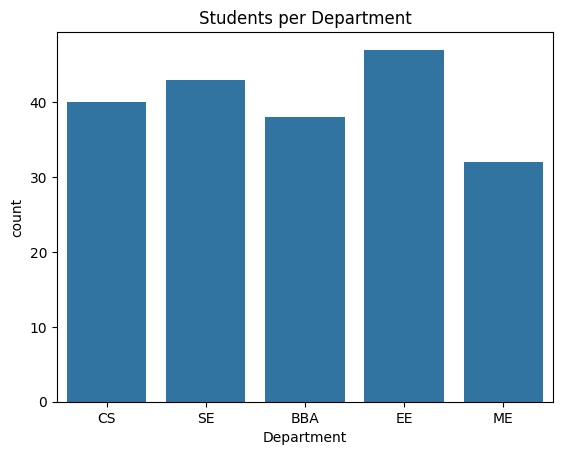

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram
sns.histplot(df['Final_Score'], kde=True)
plt.title("Distribution of Final Score")
plt.show()

# 2. Attendance vs Final Score
sns.scatterplot(x='Attendance_%', y='Final_Score', data=df)
plt.title("Attendance vs Final Score")
plt.show()

# 3. Study Hours vs Final Score
sns.scatterplot(x='Study_Hours_Daily', y='Final_Score', data=df)
plt.title("Study Hours vs Final Score")
plt.show()

# 4. Midterm vs Final Score
sns.scatterplot(x='Midterm', y='Final_Score', data=df)
plt.title("Midterm vs Final Score")
plt.show()

# 5. Heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 6. Boxplot
sns.boxplot(x='Department', y='Final_Score', data=df)
plt.title("Department vs Final Score")
plt.show()

# 7. Countplot
sns.countplot(x='Department', data=df)
plt.title("Students per Department")
plt.show()

Insights:-
1.Students with higher attendance generally achieve better final scores.
2.Midterm scores strongly influence final performance.
3.Study hours positively impact student results.

STEP 4 — Feature Engineering + Pipeline


In [ ]:
# Feature Engineering
df['Total_Academic'] = df['Midterm'] + df['Assignments']*5 + df['Quizzes']*2

# Attendance Category
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']
df['Attendance_Category'] = pd.cut(df['Attendance_%'], bins=bins, labels=labels)

Pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Split FIRST
X = df.drop(columns=['Final_Score', 'Student_ID', 'Name'])
y = df['Final_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Columns
num_cols = ['Age','Attendance_%','Study_Hours_Daily','Assignments','Quizzes','Midterm','Total_Academic']
cat_ohe = ['Gender','Internet_Access','City','Department']
cat_ord = ['Education_Level','Attendance_Category']

# Order
education_order = ['Intermediate','Bachelors','Masters']
attendance_order = ['Low','Medium','High']

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ohe', OneHotEncoder(drop='first'), cat_ohe),
    ('ord', OrdinalEncoder(categories=[education_order, attendance_order]), cat_ord)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['Education_Level',
                                                   'Attendance_Category'])])),
                ('model', LinearRegression())])

STEP 5 — Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = pipeline.predict(X_test)

# Compare
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head(10))

# Model details
model = pipeline.named_steps['model']
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

     Actual  Predicted
95     52.0  53.300545
15     47.0  52.539126
30     40.0  46.170511
158    48.0  45.326309
128    42.0  41.543140
115    43.0  42.653885
69     50.0  48.024153
170    53.0  50.702110
174    45.0  46.709255
45     41.0  49.637961
Coefficients: [ 0.07538449  1.88323922  0.35803183  0.52184701 -0.76469242  2.6356668
  1.85609623 -0.77470911 -0.18328314  0.56404052  0.37258765  1.23238667
 -0.56943077 -0.90564352  0.21282078  0.95226115  0.50582463 -0.15604629
 -0.84173699]
Intercept: 46.76338344463692

Model Evaluation:
MAE: 2.4484016880319324
RMSE: 3.2651962225522873
R²: 0.586603087562244


Visualization (Actual vs Predicted)

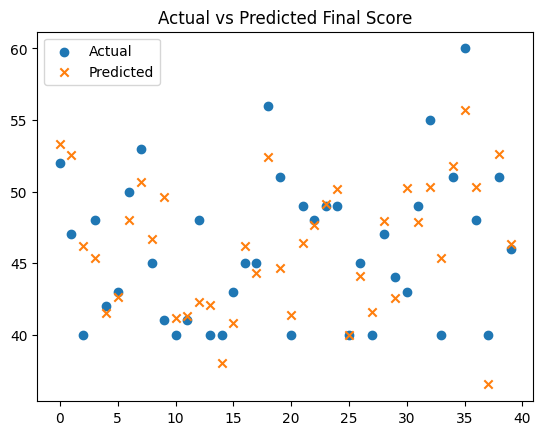

In [ ]:
plt.scatter(range(len(y_test)), y_test, label='Actual')
plt.scatter(range(len(y_test)), y_pred, marker='x', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Final Score")
plt.show()

Interpretation:-
1.The model predictions closely follow the actual values.
2.Some variation exists, but overall trend is captured well.

FINAL CONCLUSION:-

The model successfully analyzed student performance and identified key factors affecting the final score. Features such as Total_Academic, Midterm, and Attendance_% showed a strong influence on student results.

The model achieved an R² score of 0.59, which means it explains approximately 59% of the variation in Final_Score. This indicates a moderate level of predictive performance — the model is able to capture important patterns in the data, but there is still some unexplained variation.

The results suggest that academic performance and attendance play a significant role in determining final scores. However, other factors such as student motivation, learning environment, and prior knowledge may also impact performance but are not included in the dataset.

To improve the model, more relevant features could be added and advanced algorithms like Decision Trees or Random Forest could be used. Additionally, better data quality and feature selection may further enhance prediction accuracy